# CAS NLP Module 4 - Finetuning LLMs for fairy telling

**Ana Stojiljkovic and Michael Horn**

---

## Goal

Investigate how fine-tuning large language models on a domain-specific corpus (fairy tales) affects stylistic adaptation, diversity, and narrative quality.


## Models and Data

  - Models: GPT-2 small (124M), GPT-2 medium (355M), GPT-2 large (774M) and GPT-2 XL (1.5B)
  - Dataset: vicclab/fairy_tales (≈100k rows from Project Gutenberg)
  - Setup: identical fine-tuning procedure

## Methodology

  - fine-tune GPT-2 models using Hugging Face Transformers for 5 epochs
  - generate fairy-tale texts from a prompt (30 texts each)
  - evaluate with automatic metrics and qualitative analysis

## Evaluation Metrics

  - Diversity & repetition: Self-BLEU, Distinct-2
  - Fluency: Surprisal (base model)
  - Stylistic shift: Fairy-word score, zero-shot fairy-tale classifier (BART-MNLI)

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set(style="whitegrid", palette="muted", font_scale=1.2)

## Experimental Data

In [2]:
# Folder containing all experiment CSVs
DATA_DIR = Path("data_experiments")

dfs = []

model_order = ["gpt2_small", "gpt2_medium", "gpt2_large", "gpt2_xl"]
checkpoint_order = ["base", "16655", "33310", "49965", "66620", "83275"]

for csv_file in DATA_DIR.glob("*.csv"):
    # Extract model name from filename
    model_name = csv_file.stem

    df_tmp = pd.read_csv(csv_file, sep=None, engine="python")

    # Ensure checkpoint is a column (not index)
    if "checkpoint" not in df_tmp.columns:
        df_tmp = df_tmp.reset_index().rename(columns={"index": "checkpoint"})

    # Add model column
    df_tmp["model"] = model_name

    dfs.append(df_tmp)

# Concatenate all experiments into one DataFrame
df = pd.concat(dfs, ignore_index=True)

# Enforce categorical ordering
df["model"] = pd.Categorical(
    df["model"],
    categories=model_order,
    ordered=True
)

df["checkpoint"] = pd.Categorical(
    df["checkpoint"].astype(str),
    categories=checkpoint_order,
    ordered=True
)

# Final sorting
df = df.sort_values(["model", "checkpoint"]).reset_index(drop=True)

In [3]:
df 

,checkpoint,self_bleu_mean,self_bleu_std,distinct_2_mean,distinct_2_std,surprisal_mean,surprisal_std,fairy_word_mean,fairy_word_std,fairy_classifier_mean,fairy_classifier_std,model
0,base,0.487176,0.055596,0.844117,0.089136,2.151696,0.226034,3.533333,1.477235,0.565421,0.182659,gpt2_small
1,16655,0.646918,0.061039,0.818318,0.053036,2.519049,0.205091,2.833333,1.185561,0.866537,0.050683,gpt2_small
2,33310,0.661555,0.065521,0.833243,0.077689,2.601722,0.211908,3.566667,1.542365,0.841943,0.045400,gpt2_small
3,49965,0.638971,0.048203,0.822168,0.074301,2.454386,0.181512,3.566667,1.358512,0.854793,0.050334,gpt2_small
4,66620,0.636648,0.066877,0.775687,0.103671,2.420210,0.270555,2.800000,1.166190,0.871226,0.057990,gpt2_small
5,83275,0.649570,0.045245,0.776948,0.091836,2.371783,0.218567,2.866667,1.203698,0.855837,0.057275,gpt2_small
6,base,0.446734,0.072058,0.901917,0.044843,1.995990,0.184080,3.633333,1.401983,0.667875,0.179465,gpt2_medium
7,16655,0.629300,0.064278,0.868230,0.051682,2.572863,0.171840,2.866667,1.087300,0.859495,0.054878,gpt2_medium
8,33310,0.625002,0.049951,0.887423,0.036793,2.584517,0.184789,3.166667,1.368292,0.856550,0.037797,gpt2_medium
9,49965,0.581431,0.057687,0.881372,0.054860,2.501643,0.223654,3.266667,1.263153,0.877230,0.046051,gpt2_medium


---

## Self-BLEU

Self-BLEU quantifies how similar the generated samples are to each other.  
  - High Self-BLEU  → low diversity (many similar generations)
  - Low Self-BLEU   → high diversity (more varied generations)

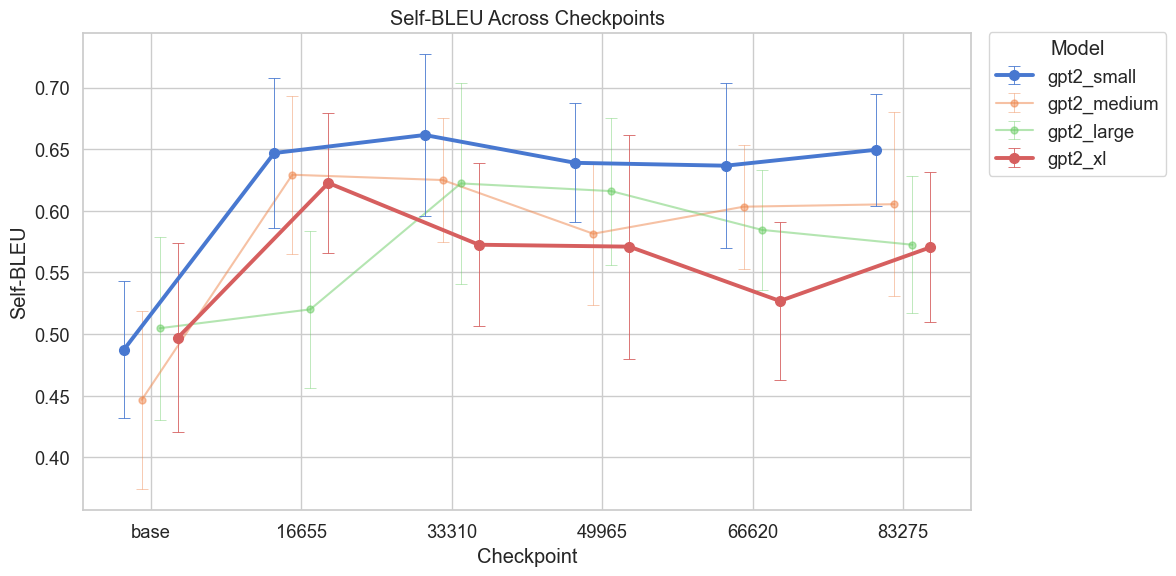

In [4]:
plt.figure(figsize=(12,6))

checkpoints = ["base","16655","33310","49965","66620","83275"]
x_base = np.arange(len(checkpoints))

models = df["model"].unique()
offset = 0.12

# Visual emphasis settings
style = {
    "gpt2_small":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_xl":     {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_medium": {"alpha": 0.5, "lw": 1.5, "ms": 5, "z": 1},
    "gpt2_large":  {"alpha": 0.5, "lw": 1.5, "ms": 5, "z": 1},
}

for i, model in enumerate(models):
    subset = (
        df[df["model"] == model]
        .set_index("checkpoint")
        .loc[checkpoints]
        .reset_index()
    )

    # Horizontal offset so models don’t overlap
    x = x_base + (i - (len(models) - 1) / 2) * offset

    plt.errorbar(
        x,
        subset["self_bleu_mean"],
        yerr=subset["self_bleu_std"],
        marker="o",
        capsize=4,
        elinewidth=0.6,
        capthick=0.6,
        label=model,
        alpha=style[model]["alpha"],
        linewidth=style[model]["lw"],
        markersize=style[model]["ms"],
        zorder=style[model]["z"]
    )

plt.title("Self-BLEU Across Checkpoints")
plt.ylabel("Self-BLEU")
plt.xlabel("Checkpoint")
plt.xticks(x_base, checkpoints)

plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1.01, 1.02))
plt.tight_layout()
#plt.savefig("self_bleu.png", dpi=300, bbox_inches="tight")
plt.show()



**Observed trends**: 
  - self-BLEU increases after fine-tuning for all models  
  - increase is stronger for smaller models

**Interpretation**:   
Fine-tuning on fairy tales constrains the stylistic space of the models:
  - the models learn recurrent narative patterns
  - this results in (a size dependent) greater stylistic coherence at the cost of generative diversity

**Conclusion**:   
Fine-tuning successfully induces a shared fairy-tale style, at the cost of some generative diversity.

---

## Lexical Diversity

Distinct-2 measures the proportion of unique bigrams.

  - Higher Distinct-2 → more diverse and less repetitive text
  - Lower Distinct-2  → more repetition

(It is a metric complementary to self-BLEU.)

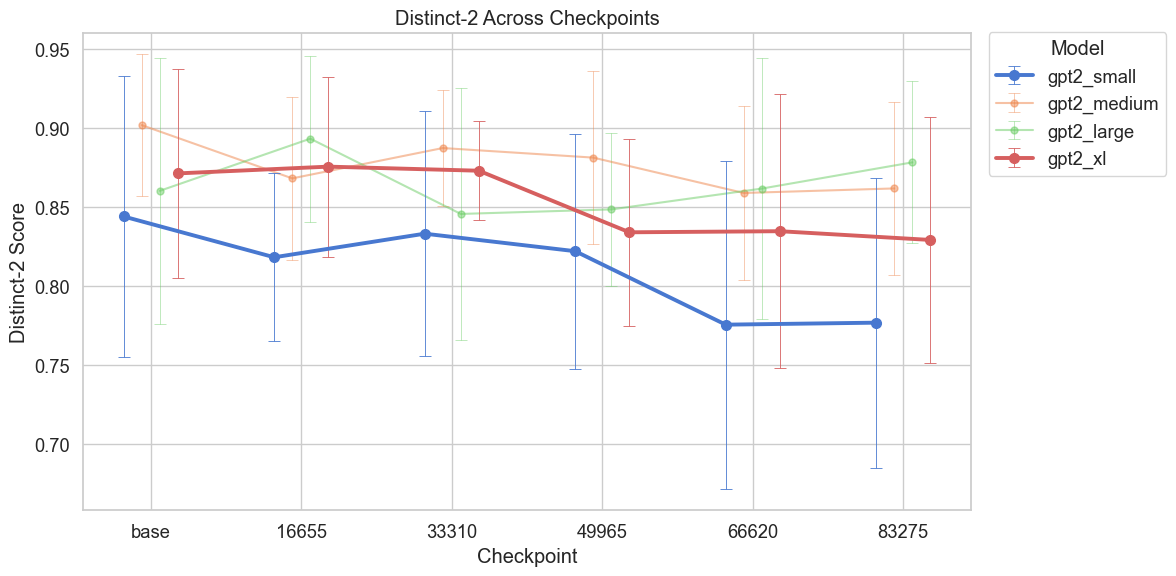

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

checkpoints = ["base","16655","33310","49965","66620","83275"]
x_base = np.arange(len(checkpoints))

models = df["model"].unique()
offset = 0.12

style = {
    "gpt2_small":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_xl":     {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_medium": {"alpha": 0.5, "lw": 1.5, "ms": 5, "z": 1},
    "gpt2_large":  {"alpha": 0.5, "lw": 1.5, "ms": 5, "z": 1},
}

for i, model in enumerate(models):
    subset = (
        df[df["model"] == model]
        .set_index("checkpoint")
        .loc[checkpoints]
        .reset_index()
    )

    # Horizontal offset so models don’t overlap
    x = x_base + (i - (len(models) - 1) / 2) * offset

    plt.errorbar(
        x,
        subset["distinct_2_mean"],
        yerr=subset["distinct_2_std"],
        marker="o",
        capsize=4,
        elinewidth=0.6,     # thin error bars
        capthick=0.6,
        label=model,
        alpha=style[model]["alpha"],
        linewidth=style[model]["lw"],
        markersize=style[model]["ms"],
        zorder=style[model]["z"]
    )

plt.title("Distinct-2 Across Checkpoints")
plt.ylabel("Distinct-2 Score")
plt.xlabel("Checkpoint")
plt.xticks(x_base, checkpoints)

plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1.01, 1.02))
plt.tight_layout()
#plt.savefig("lexical_diversity.png", dpi=300, bbox_inches="tight")
plt.show()

**Observed trends**: 
  - distinct-2 decreases slightly after fine-tuning (mostly visible for gpt2_small and gpt2_xl)
  - larger models retain higher absolute Distinct-2 than smaller ones

**Interpretation**:  
Fine-tuning encourages:
  - reuse of genre-specific phrases
  - increased bigram repetition due to formulaic narrative structure

**Conclusion**:  
Lexical diversity is slightly reduced suggesting style learning.

---

## Surprisal (under the base model)

Surprisal measures how unexpected a text is to the base (non-finetuned) model:  
  - Lower surprisal → text is more likely / more familiar to the model (closer to base distribution)
  - Higher surprisal → text is more unexpected (stronger domain shift)

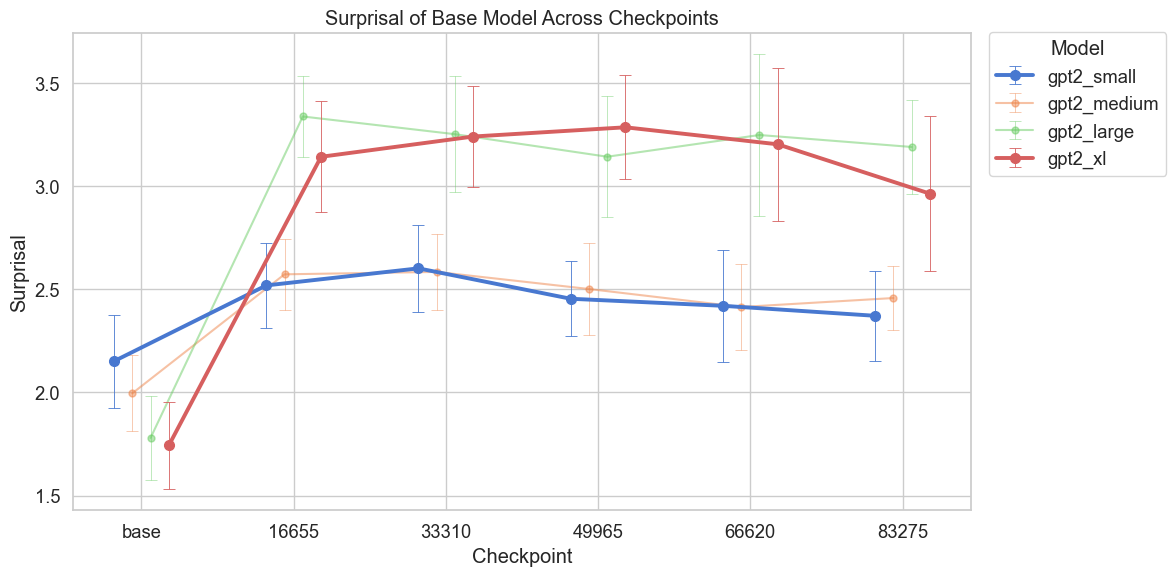

In [6]:
plt.figure(figsize=(12,6))

checkpoints = ["base","16655","33310","49965","66620","83275"]
x_base = np.arange(len(checkpoints))

models = df["model"].unique()
offset = 0.12

style = {
    "gpt2_small":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_xl":     {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_medium": {"alpha": 0.5, "lw": 1.5, "ms": 5, "z": 1},
    "gpt2_large":  {"alpha": 0.5, "lw": 1.5, "ms": 5, "z": 1},
}

for i, model in enumerate(models):
    subset = (
        df[df["model"] == model]
        .set_index("checkpoint")
        .loc[checkpoints]
        .reset_index()
    )

    # Horizontal offset so models don’t overlap
    x = x_base + (i - (len(models) - 1) / 2) * offset

    plt.errorbar(
        x,
        subset["surprisal_mean"],
        yerr=subset["surprisal_std"],
        marker="o",
        capsize=4,
        elinewidth=0.6,   # thin error bars
        capthick=0.6,
        label=model,
        alpha=style[model]["alpha"],
        linewidth=style[model]["lw"],
        markersize=style[model]["ms"],
        zorder=style[model]["z"]
    )

plt.title("Surprisal of Base Model Across Checkpoints")
plt.ylabel("Surprisal")
plt.xlabel("Checkpoint")
plt.xticks(x_base, checkpoints)

plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1.01, 1.02))
plt.tight_layout()
#plt.savefig("surprisal.png", dpi=300, bbox_inches="tight")
plt.show()

**Observed trends**:  
  - surprisal increases sharply after fine-tuning for all models  
  - larger models show stronger increases

**Interpretation**:  
Fine-tuned models produce text that:
  - deviates significantly from general-domain language
  - is statistically “surprising” to the base model

**Conclusion**:  
Fine-tuning induces a distributional shift, especially in larger models.

---

## Fairy Word Score

Counts the number of words in a text that belong to a predefined “fairy tale vocabulary”. Higher scores indicate more fairy-tale–like content. 

In [7]:
fairy_words = {
    # Core beings & roles
    "fairy", "fairies", "king", "queen", "prince", "princess",
    "witch", "wizard", "sorcerer", "sorceress", "mage",
    "giant", "ogre", "dragon", "elf", "dwarf", "goblin",
    "knight", "hero", "villain",

    # Magic & supernatural
    "magic", "magical", "spell", "spells", "curse", "cursed",
    "enchantment", "enchanted", "charm", "potion",
    "wand", "crystal", "prophecy", "destiny",

    # Places & settings
    "forest", "woods", "kingdom", "castle", "tower",
    "palace", "village", "cottage", "hut",
    "mountain", "cave", "river", "lake",

    # Objects & symbols
    "crown", "throne", "sword", "shield", "cloak",
    "ring", "mirror", "key", "treasure", "gold",
    "apple", "rose", "needle",

    # Fairy-tale actions & themes
    "wish", "wished", "dream", "dreamed",
    "journey", "quest", "trial",
    "promise", "forbidden",
    "curse", "blessing",
    "transformed", "transformation",

    # Narrative markers
    "once", "kingdom", "ancient", "mystical",
    "legend", "tale", "story", "myth"
}

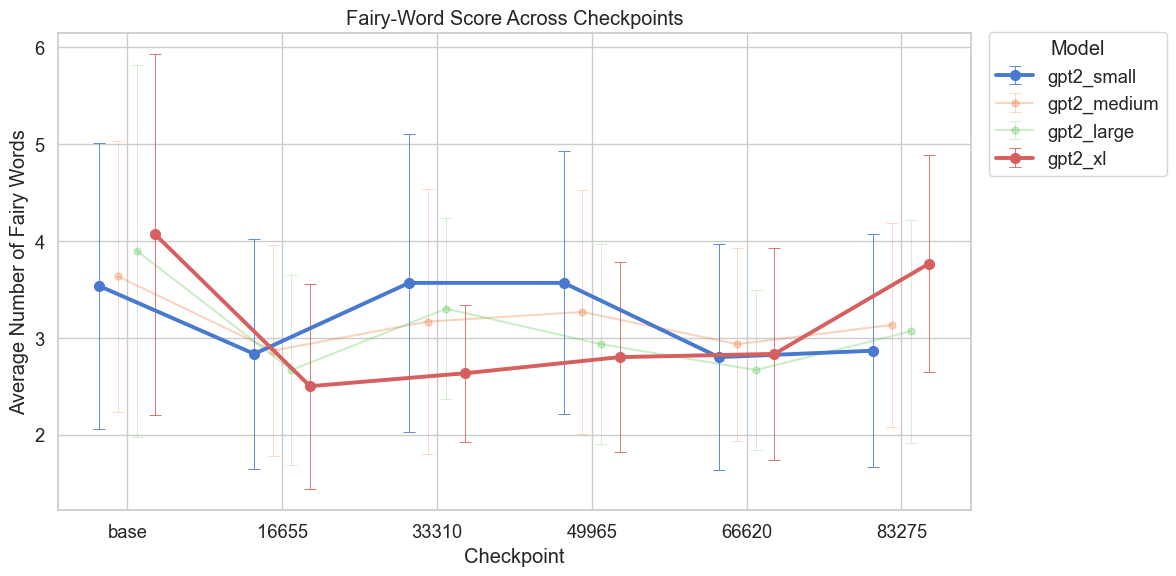

In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

checkpoints = ["base","16655","33310","49965","66620","83275"]
x_base = np.arange(len(checkpoints))

models = df["model"].unique()
offset = 0.12

# Style settings to emphasize small and XL
style = {
    "gpt2_small":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_xl":     {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_medium": {"alpha": 0.35, "lw": 1.5, "ms": 5, "z": 1},
    "gpt2_large":  {"alpha": 0.35, "lw": 1.5, "ms": 5, "z": 1},
}

for i, model in enumerate(models):
    subset = (
        df[df["model"] == model]
        .set_index("checkpoint")
        .loc[checkpoints]
        .reset_index()
    )

    # Horizontal offset so models don’t overlap
    x = x_base + (i - (len(models) - 1) / 2) * offset

    plt.errorbar(
        x,
        subset["fairy_word_mean"],
        yerr=subset["fairy_word_std"],
        marker="o",
        capsize=4,
        elinewidth=0.6,
        capthick=0.6,
        label=model,
        alpha=style[model]["alpha"],
        linewidth=style[model]["lw"],
        markersize=style[model]["ms"],
        zorder=style[model]["z"]
    )

plt.title("Fairy-Word Score Across Checkpoints")
plt.ylabel("Average Number of Fairy Words")
plt.xlabel("Checkpoint")
plt.xticks(x_base, checkpoints)

plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1.01, 1.02))
plt.tight_layout()
#plt.savefig("fairy_word_score.png", dpi=300, bbox_inches="tight")
plt.show()

**Observed trends**:  
  - no monotonic increase with fine-tuning  
  - decreases initially, then fluctuates  
  - variance is quite high

**Interpretation**: 
Fine-tuning does not simply increase keyword usage. Instead, models might rather learn how to tell fairy tales, not just which words to use.

---

## Fairy Classifier

  - Input: a generated text (or list of texts)
  - Candidate labels: e.g., ["fairy tale", "non-fairy tale"]
  - Output: probability/confidence that the text is a fairy tale

**bart-large-mnli**:  
  - a sequence-to-sequence transformer model (BART) fine-tuned on MNLI (Multi-Genre Natural Language Inference)
  - allows zero-shot classification without fine-tuning
  - is large enough to understand nuanced stylistic cues and therefore detect stylistic differences
  - is robust and widely used 

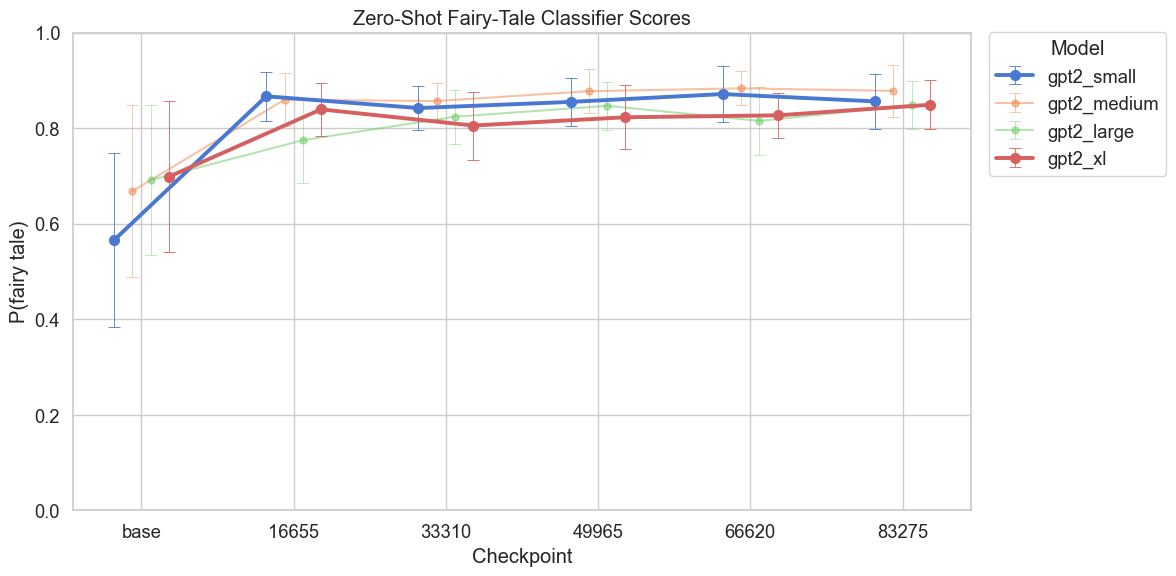

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

checkpoints = ["base","16655","33310","49965","66620","83275"]
x_base = np.arange(len(checkpoints))

models = df["model"].unique()
offset = 0.12

# Visual emphasis settings
highlight_models = {"gpt2_small", "gpt2_xl"}

style = {
    "gpt2_small":  {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_xl":     {"alpha": 1.0, "lw": 2.8, "ms": 7, "z": 3},
    "gpt2_medium": {"alpha": 0.5, "lw": 1.5, "ms": 5, "z": 1},
    "gpt2_large":  {"alpha": 0.5, "lw": 1.5, "ms": 5, "z": 1},
}

for i, model in enumerate(models):
    subset = (
        df[df["model"] == model]
        .set_index("checkpoint")
        .loc[checkpoints]
        .reset_index()
    )

    x = x_base + (i - (len(models)-1)/2) * offset

    plt.errorbar(
        x,
        subset["fairy_classifier_mean"],
        yerr=subset["fairy_classifier_std"],
        marker="o",
        capsize=4,
        elinewidth=0.6,
        capthick=0.6,
        label=model,
        alpha=style[model]["alpha"],
        linewidth=style[model]["lw"],
        markersize=style[model]["ms"],
        zorder=style[model]["z"]
    )

plt.title("Zero-Shot Fairy-Tale Classifier Scores")
plt.ylabel("P(fairy tale)")
plt.xlabel("Checkpoint")
plt.xticks(x_base, checkpoints)
plt.ylim(0, 1)

plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1.01, 1.02))
plt.tight_layout()
#plt.savefig("fairy_tale_classifier.png", dpi=300, bbox_inches="tight")
plt.show()


**Observed trends**:
  - consistent increase across all model sizes
  - smaller models show higher increase  

**Interpretation**:  
  - fine-tuning produces consistent fairy-tale style  
  - reduced variance indicates reliable stylistic control
  - the effect is stronger for smaller models

**Conclusion**:  
Fine-tuning is effective at inducing global fairy-tale style. Smaller models seem to profit more from fine-tuning than larger models.

---

## Conclusion

Fine-tuning on fairy tales increases stylistic adaptation: Self-BLEU and surprisal rise, Distinct-2 decreases slightly, and fairy-classifier scores peak in smaller models. This indicates effective genre learning and narrative adaptation, with improvements driven by structural style rather than keyword frequency.

---

## Appendix

### Fairy word occurency in data set

In [10]:
from datasets import load_dataset
from collections import Counter
import pandas as pd

# Load the fairy tale dataset from Hugging Face
# This dataset contains fairy tale texts split into train/validation/test
dataset = load_dataset("vicclab/fairy_tales")

# Extract the raw text from the training split
texts = dataset["train"]["text"]

# We use a simple whitespace-based tokenization here
# (lowercasing ensures case-insensitive counting)
all_tokens = []
for text in texts:
    all_tokens.extend(text.lower().split())

# Count how often each token appears in the dataset
token_counts = Counter(all_tokens)

# For each word in the fairy_words list, retrieve its frequency
# Only include words that actually appear in the dataset
fairy_word_counts = {
    word: token_counts[word]
    for word in fairy_words
    if word in token_counts
}

# Convert to DataFrame
df_fairy_words = (
    pd.DataFrame(
        fairy_word_counts.items(),
        columns=["fairy_word", "count"]
    )
    .sort_values("count", ascending=False)
)


C:\Users\micha\anaconda3\envs\transformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


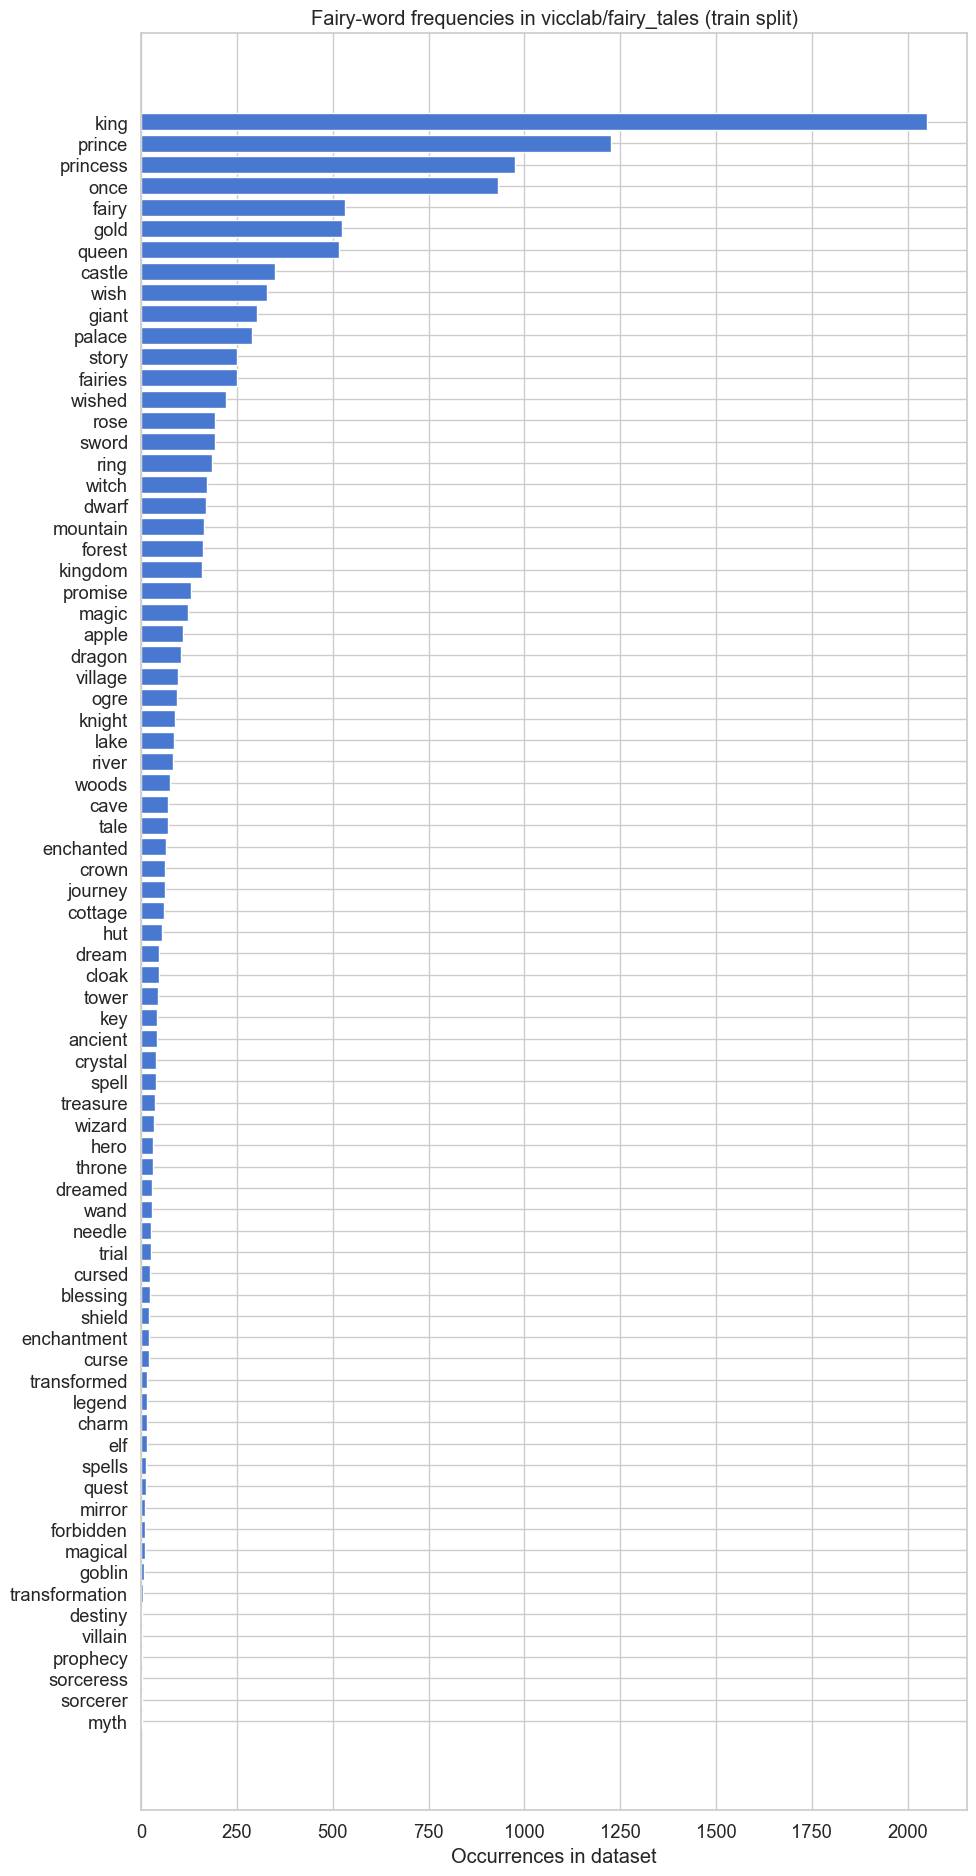

In [11]:
plt.figure(figsize=(10, max(4, len(df_fairy_words) * 0.25)))
plt.barh(df_fairy_words["fairy_word"], df_fairy_words["count"])
plt.xlabel("Occurrences in dataset")
plt.title("Fairy-word frequencies in vicclab/fairy_tales (train split)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
coverage = len(df_fairy_words) / len(fairy_words)
print(f"Fairy-word vocabulary coverage: {coverage:.2%}")

Fairy-word vocabulary coverage: 96.20%
